In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_val_score,
    GridSearchCV
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

In [2]:
df = pd.read_csv("../data/student-mat.csv")

print(df.shape)
df.head()

(395, 1)


,school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3
0,"GP;""F"";18;""U"";""GT3"";""A"";4;4;""at_home"";""teacher..."
1,"GP;""F"";17;""U"";""GT3"";""T"";1;1;""at_home"";""other"";..."
2,"GP;""F"";15;""U"";""LE3"";""T"";1;1;""at_home"";""other"";..."
3,"GP;""F"";15;""U"";""GT3"";""T"";4;2;""health"";""services..."
4,"GP;""F"";16;""U"";""GT3"";""T"";3;3;""other"";""other"";""h..."


In [6]:
print(df.columns.tolist())

['school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3']


In [7]:
print(df.shape)
print(df.head())

(395, 1)
  school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3
0  GP;"F";18;"U";"GT3";"A";4;4;"at_home";"teacher...                                                                                                                                                                                 
1  GP;"F";17;"U";"GT3";"T";1;1;"at_home";"other";...                                                                                                                                                                                 
2  GP;"F";15;"U";"LE3";"T";1;1;"at_home";"other";...                                                                                                                                                                                 
3  GP;"F";15;"U";"GT3";"T";4;2;"health";"services...                   

In [8]:
print("G3" in df.columns)

False


In [9]:
print(df.columns.tolist())
print(df.head())

['school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3']
  school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3
0  GP;"F";18;"U";"GT3";"A";4;4;"at_home";"teacher...                                                                                                                                                                                 
1  GP;"F";17;"U";"GT3";"T";1;1;"at_home";"other";...                                                                                                                                                                                 
2  GP;"F";15;"U";"LE3";"T";1;1;"at_home";"other";...                          

In [10]:
df = pd.read_csv("../data/student-mat.csv")

In [11]:
df = pd.read_csv("../data/student-mat.csv", sep=";")

In [12]:
print(df.columns.tolist())

['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


In [13]:
print(df.shape)

(395, 33)


In [14]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [15]:
print(df["G3"].head())

0     6
1     6
2    10
3    15
4    10
Name: G3, dtype: int64


In [16]:
X = df.drop("G3", axis=1)
y = df["G3"]

In [17]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (395, 32)
y shape: (395,)


In [19]:
from sklearn.model_selection import train_test_split

X = df.drop("G3", axis=1)
y = df["G3"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_cols = X.select_dtypes(
    include=["object"]
).columns

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_cols
        )
    ],
    remainder="passthrough"
)

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor

dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(random_state=42))
])

In [22]:
dt_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](32,)","['school','sex','age',...,'absences','G1','G2']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,32
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the

In [23]:
y_pred = dt_pipeline.predict(X_test)

In [24]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 1.2784810126582278
MSE : 5.481012658227848
RMSE: 2.3411562652304627
R²  : 0.7326993404807303


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training set:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting set:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Training set:
X_train: (316, 32)
y_train: (316,)

Testing set:
X_test: (79, 32)
y_test: (79,)


In [27]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor

In [28]:
categorical_cols = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Categorical columns:")
print(categorical_cols)

Categorical columns:
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


In [29]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_cols
        )
    ],
    remainder="passthrough"
)

In [30]:
dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(random_state=42))
])

In [32]:
dt_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](32,)","['school','sex','age',...,'absences','G1','G2']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,32
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the outpu

In [33]:
y_pred = dt_pipeline.predict(X_test)

print(y_pred[:10])

[ 8. 12.  8. 10. 10. 11. 20.  5.  9. 14.]


In [34]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Decision Tree Performance")
print("--------------------------")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

Decision Tree Performance
--------------------------
MAE : 1.2784810126582278
MSE : 5.481012658227848
RMSE: 2.3411562652304627
R²  : 0.7326993404807303


In [35]:
y_train_pred = dt_pipeline.predict(X_train)

train_rmse = np.sqrt(
    mean_squared_error(y_train, y_train_pred)
)

test_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

print("Training RMSE:", train_rmse)
print("Testing RMSE :", test_rmse)

Training RMSE: 0.0
Testing RMSE : 2.3411562652304627


In [36]:
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    dt_pipeline,
    X,
    y,
    cv=kf,
    scoring="neg_root_mean_squared_error"
)

cv_rmse = -cv_scores

print("5-Fold Cross-Validation RMSE:")
print(cv_rmse)

print("\nMean CV RMSE:", cv_rmse.mean())
print("Standard Deviation:", cv_rmse.std())

5-Fold Cross-Validation RMSE:
[2.34115627 2.38932224 1.73934369 1.83496284 2.78785794]

Mean CV RMSE: 2.2185285930958623
Standard Deviation: 0.38602714615096945


In [37]:
# Predictions on training data
y_train_pred = dt_pipeline.predict(X_train)

# Predictions on testing data
y_test_pred = dt_pipeline.predict(X_test)

# RMSE
train_rmse = np.sqrt(
    mean_squared_error(y_train, y_train_pred)
)

test_rmse = np.sqrt(
    mean_squared_error(y_test, y_test_pred)
)

# R²
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Training Performance")
print("--------------------")
print("RMSE:", train_rmse)
print("R²  :", train_r2)

print("\nTesting Performance")
print("-------------------")
print("RMSE:", test_rmse)
print("R²  :", test_r2)

Training Performance
--------------------
RMSE: 0.0
R²  : 1.0

Testing Performance
-------------------
RMSE: 2.3411562652304627
R²  : 0.7326993404807303


In [38]:
rmse_gap = test_rmse - train_rmse
r2_gap = train_r2 - test_r2

print("RMSE Gap:", rmse_gap)
print("R² Gap:", r2_gap)

RMSE Gap: 2.3411562652304627
R² Gap: 0.26730065951926973


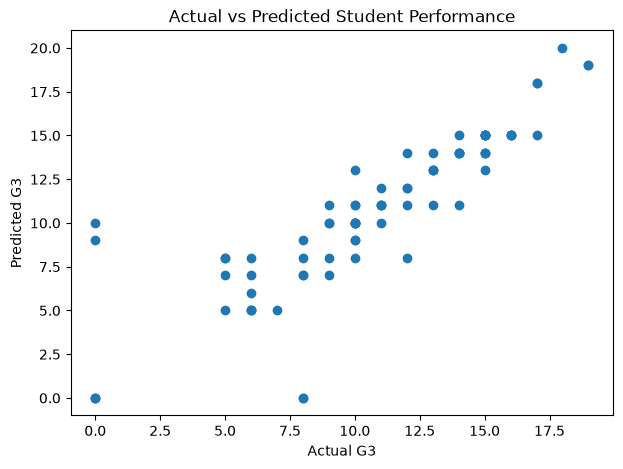

In [39]:
plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_test_pred)

plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.title("Actual vs Predicted Student Performance")

plt.show()

In [40]:
residuals = y_test - y_test_pred

print(residuals.describe())

count    79.000000
mean      0.037975
std       2.355806
min     -10.000000
25%      -1.000000
50%       0.000000
75%       1.000000
max       8.000000
Name: G3, dtype: float64


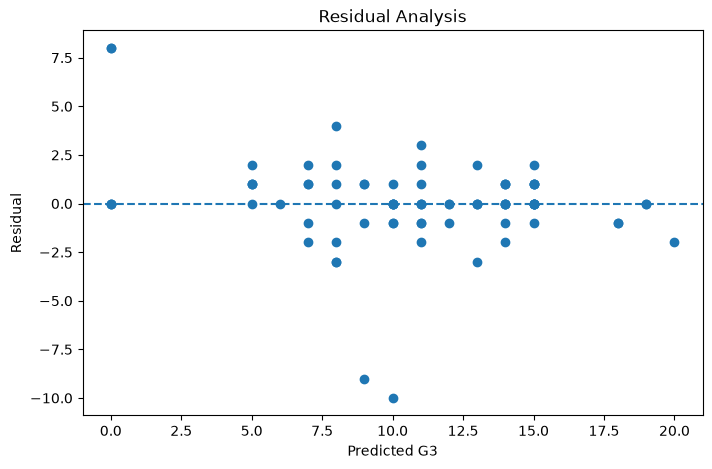

In [41]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test_pred, residuals)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted G3")
plt.ylabel("Residual")
plt.title("Residual Analysis")

plt.show()

In [42]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__max_depth": [2, 3, 4, 5, 6, 8, 10, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

In [43]:
grid_search = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    return_train_score=True
)

In [44]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [2, 3, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available 

In [45]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 10}


In [46]:
best_cv_rmse = -grid_search.best_score_

print("Best Cross-Validation RMSE:", best_cv_rmse)

Best Cross-Validation RMSE: 1.8201268094696492


In [47]:
optimized_dt = grid_search.best_estimator_

print(optimized_dt)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['school', 'sex', 'address',
                                                   'famsize', 'Pstatus', 'Mjob',
                                                   'Fjob', 'reason', 'guardian',
                                                   'schoolsup', 'famsup',
                                                   'paid', 'activities',
                                                   'nursery', 'higher',
                                                   'internet', 'romantic'])])),
                ('model',
                 DecisionTreeRegressor(max_depth=5, min_samples_split=10,
                                       random_state=42))])


In [48]:
optimized_pred = optimized_dt.predict(X_test)

optimized_mae = mean_absolute_error(
    y_test,
    optimized_pred
)

optimized_mse = mean_squared_error(
    y_test,
    optimized_pred
)

optimized_rmse = np.sqrt(
    optimized_mse
)

optimized_r2 = r2_score(
    y_test,
    optimized_pred
)

print("Optimized Decision Tree")
print("-----------------------")
print("MAE :", optimized_mae)
print("MSE :", optimized_mse)
print("RMSE:", optimized_rmse)
print("R²  :", optimized_r2)

Optimized Decision Tree
-----------------------
MAE : 1.4395200531138892
MSE : 6.65281263189969
RMSE: 2.579304679928234
R²  : 0.6755524361916203


In [49]:
baseline_results = {
    "MAE": mae,
    "MSE": mse,
    "RMSE": rmse,
    "R2": r2
}

optimized_results = {
    "MAE": optimized_mae,
    "MSE": optimized_mse,
    "RMSE": optimized_rmse,
    "R2": optimized_r2
}

comparison = pd.DataFrame({
    "Baseline Decision Tree": baseline_results,
    "Optimized Decision Tree": optimized_results
}).T

comparison

,MAE,MSE,RMSE,R2
Baseline Decision Tree,1.278481,5.481013,2.341156,0.732699
Optimized Decision Tree,1.439520,6.652813,2.579305,0.675552


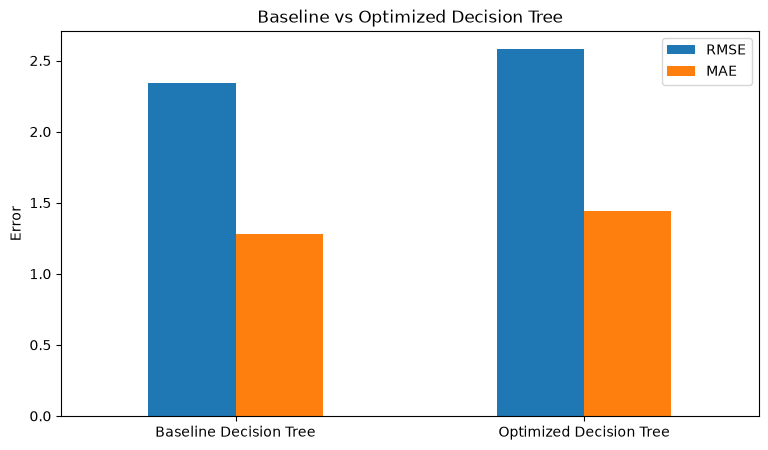

In [50]:
comparison[["RMSE", "MAE"]].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Baseline vs Optimized Decision Tree")
plt.ylabel("Error")
plt.xticks(rotation=0)
plt.show()

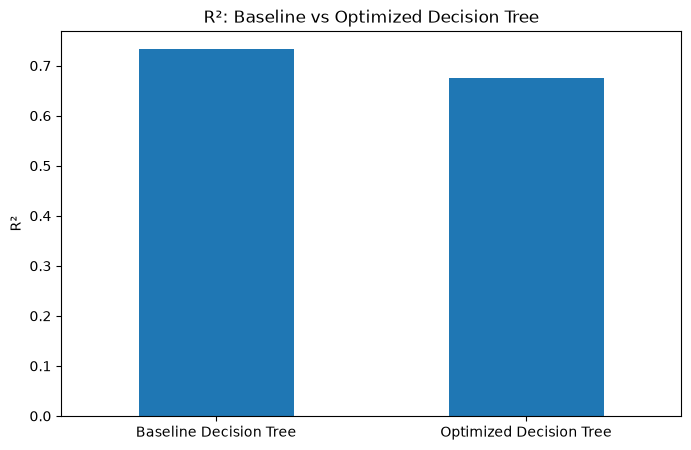

In [51]:
comparison["R2"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("R²: Baseline vs Optimized Decision Tree")
plt.ylabel("R²")
plt.xticks(rotation=0)
plt.show()

In [52]:
optimized_train_pred = optimized_dt.predict(X_train)

optimized_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        optimized_train_pred
    )
)

optimized_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        optimized_pred
    )
)

optimized_train_r2 = r2_score(
    y_train,
    optimized_train_pred
)

optimized_test_r2 = r2_score(
    y_test,
    optimized_pred
)

print("Optimized Training RMSE:", optimized_train_rmse)
print("Optimized Testing RMSE :", optimized_test_rmse)

print("\nOptimized Training R²:", optimized_train_r2)
print("Optimized Testing R² :", optimized_test_r2)

Optimized Training RMSE: 1.0536034383995356
Optimized Testing RMSE : 2.579304679928234

Optimized Training R²: 0.9471504042852725
Optimized Testing R² : 0.6755524361916203


In [53]:
# Get the preprocessing step
preprocessor_fitted = optimized_dt.named_steps["preprocessor"]

# Get the Decision Tree model
tree_model = optimized_dt.named_steps["model"]

# Get encoded feature names
encoded_features = preprocessor_fitted.get_feature_names_out()

# Create feature importance table
feature_importance = pd.DataFrame({
    "Feature": encoded_features,
    "Importance": tree_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
57,remainder__G2,0.779482
55,remainder__absences,0.162020
21,categorical__reason_home,0.036436
11,categorical__Mjob_health,0.011464
53,remainder__Walc,0.003194
22,categorical__reason_other,0.002643
51,remainder__goout,0.002017
56,remainder__G1,0.001287
24,categorical__guardian_father,0.000619
43,remainder__age,0.000427


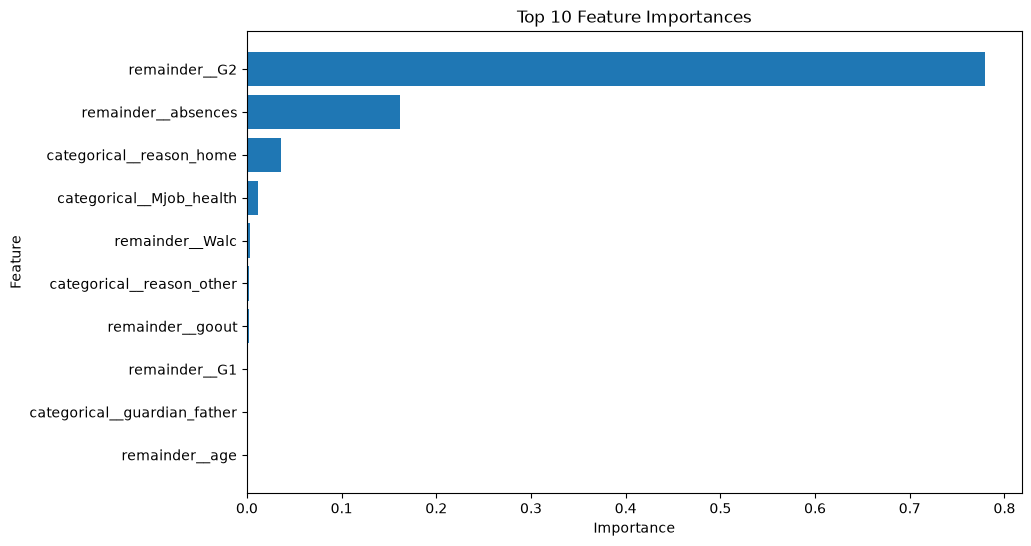

In [54]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances")

plt.gca().invert_yaxis()

plt.show()

In [ ]:
final_comparison = pd.DataFrame({
    "Baseline Decision Tree": baseline_results,
    "Optimized Decision Tree": optimized_results
}).T

final_comparison

In [57]:
cv_summary = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    "RMSE": cv_rmse
})

cv_summary.loc[len(cv_summary)] = [
    "Mean",
    cv_rmse.mean()
]

cv_summary.loc[len(cv_summary)] = [
    "Std",
    cv_rmse.std()
]

print(cv_summary)

   Fold      RMSE
0     1  2.341156
1     2  2.389322
2     3  1.739344
3     4  1.834963
4     5  2.787858
5  Mean  2.218529
6   Std  0.386027


In [58]:
cv_summary.to_csv(
    "../reports/week4_cross_validation.csv",
    index=False
)

print("Cross-validation results saved successfully.")

Cross-validation results saved successfully.


In [59]:
import os

print(
    os.path.exists(
        "../reports/week4_decision_tree_comparison.csv"
    )
)

print(
    os.path.exists(
        "../reports/week4_cross_validation.csv"
    )
)

False
True


In [60]:
evaluation_summary = pd.DataFrame({
    "Model": [
        "Baseline Decision Tree",
        "Optimized Decision Tree"
    ],
    "MAE": [
        mae,
        optimized_mae
    ],
    "MSE": [
        mse,
        optimized_mse
    ],
    "RMSE": [
        rmse,
        optimized_rmse
    ],
    "R2": [
        r2,
        optimized_r2
    ]
})

evaluation_summary

,Model,MAE,MSE,RMSE,R2
0,Baseline Decision Tree,1.278481,5.481013,2.341156,0.732699
1,Optimized Decision Tree,1.439520,6.652813,2.579305,0.675552


In [61]:

evaluation_summary.to_csv(
    "../reports/week4_evaluation_summary.csv",
    index=False
)

print("Evaluation summary saved successfully.")


Evaluation summary saved successfully.


In [62]:
import joblib

joblib.dump(
    optimized_dt,
    "../reports/optimized_decision_tree.pkl"
)

print("Optimized Decision Tree saved successfully.")

Optimized Decision Tree saved successfully.


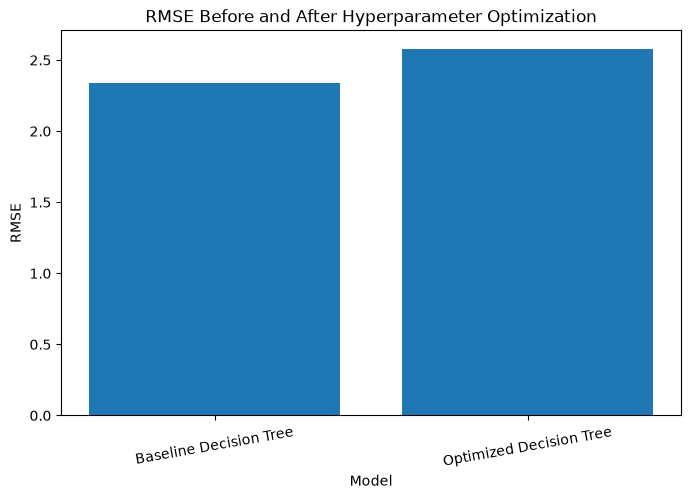

In [63]:
plt.figure(figsize=(8, 5))

models = [
    "Baseline Decision Tree",
    "Optimized Decision Tree"
]

rmse_values = [
    rmse,
    optimized_rmse
]

plt.bar(models, rmse_values)

plt.ylabel("RMSE")
plt.xlabel("Model")
plt.title("RMSE Before and After Hyperparameter Optimization")

plt.xticks(rotation=10)

plt.show()

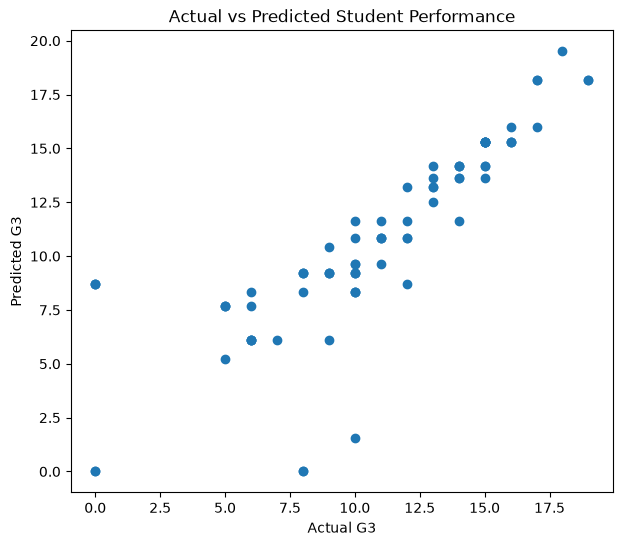

In [64]:
plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    optimized_pred
)

plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.title("Actual vs Predicted Student Performance")

plt.show()

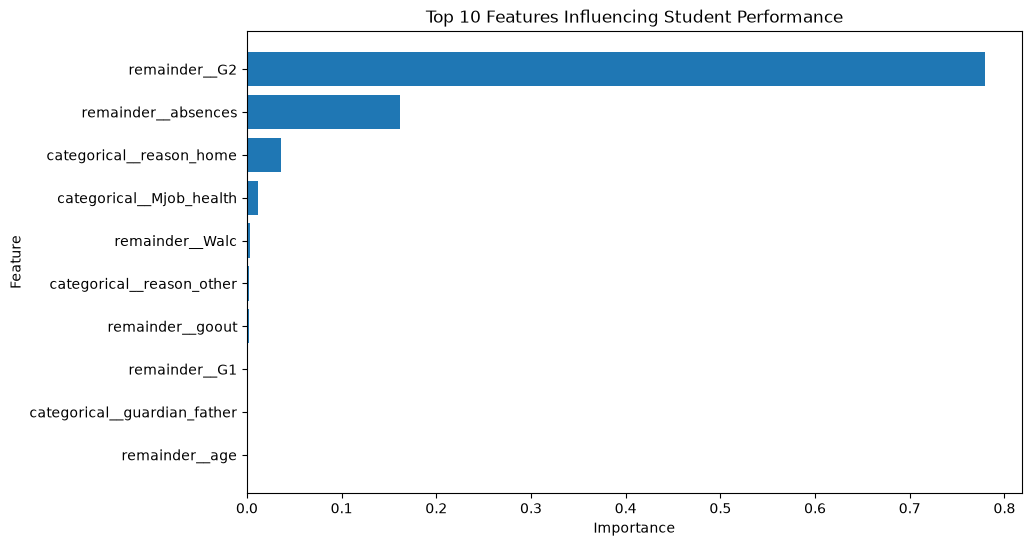

In [65]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Features Influencing Student Performance")

plt.gca().invert_yaxis()

plt.show()

In [66]:
print("===== FINAL EVALUATION =====")
print(evaluation_summary)

print("\n===== CROSS VALIDATION =====")
print(cv_summary)

print("\n===== BEST PARAMETERS =====")
print(grid_search.best_params_)

===== FINAL EVALUATION =====
                     Model       MAE       MSE      RMSE        R2
0   Baseline Decision Tree  1.278481  5.481013  2.341156  0.732699
1  Optimized Decision Tree  1.439520  6.652813  2.579305  0.675552

===== CROSS VALIDATION =====
   Fold      RMSE
0     1  2.341156
1     2  2.389322
2     3  1.739344
3     4  1.834963
4     5  2.787858
5  Mean  2.218529
6   Std  0.386027

===== BEST PARAMETERS =====
{'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 10}
